# Fast-DetectGPT Testset Threshold Analysis

This notebook fits Fast-DetectGPT single-threshold and double-threshold classifiers on the official Task A training split using the same balanced 2000-row calibration subset and double-threshold grid used by `fast_detect_gpt_double_threshold.ipynb`. It then evaluates both strategies on the first 1000 rows of the official Hugging Face Task A `test` split and plots the test discrepancy distribution with the fitted thresholds.


## Setup

In [1]:
# Check environment and install dependencies
import os
import sys

IS_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules
print(f"Running on {'Google Colab' if IS_COLAB else 'Local Machine'}")

if IS_COLAB:
    print("Installing requirements for Google Colab...")
    !pip install -q "datasets==4.3.0" "huggingface_hub>=0.34.0" transformers accelerate pandas pyarrow tqdm scikit-learn matplotlib seaborn torch
else:
    print("Local environment detected. Ensure transformers, datasets, torch, pandas, pyarrow, matplotlib, seaborn, and scikit-learn are installed.")


Running on Google Colab
Installing requirements for Google Colab...


## Configuration

In [ ]:
import random
import numpy as np
import torch

DATASET_NAME = "DaniilOr/SemEval-2026-Task13"
DATASET_CONFIG = "A"
MODEL_NAME = "stabilityai/stable-code-3b"
TRAIN_THRESHOLD_SAMPLES = 2000
TEST_SAMPLES = 1000
SINGLE_THRESHOLD_GRID_SIZE = 200
DOUBLE_THRESHOLD_GRID_SIZE = 100
MAX_LENGTH = 512
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Load Model

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

print(f"Loading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading model for {MODEL_NAME}...")
torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    device_map="auto" if device == "cuda" else None,
    trust_remote_code=True,
)
model.eval()
print("Model loaded.")


Using device: cuda
Loading tokenizer for codellama/CodeLlama-7b-Instruct-hf...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading model for codellama/CodeLlama-7b-Instruct-hf...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded.


## Fast-DetectGPT Score

In [4]:
def get_sampling_discrepancy_analytic(logits_ref, logits_score, labels):
    assert logits_ref.shape[0] == 1
    assert logits_score.shape[0] == 1
    assert labels.shape[0] == 1

    if logits_ref.size(-1) != logits_score.size(-1):
        vocab_size = min(logits_ref.size(-1), logits_score.size(-1))
        logits_ref = logits_ref[:, :, :vocab_size]
        logits_score = logits_score[:, :, :vocab_size]

    labels = labels.unsqueeze(-1) if labels.ndim == logits_score.ndim - 1 else labels
    lprobs_score = torch.log_softmax(logits_score, dim=-1)
    probs_ref = torch.softmax(logits_ref, dim=-1)

    log_likelihood = lprobs_score.gather(dim=-1, index=labels).squeeze(-1)
    mean_ref = (probs_ref * lprobs_score).sum(dim=-1)
    var_ref = (probs_ref * torch.square(lprobs_score)).sum(dim=-1) - torch.square(mean_ref)

    discrepancy = (log_likelihood.sum(dim=-1) - mean_ref.sum(dim=-1)) / (var_ref.sum(dim=-1).sqrt() + 1e-8)
    return discrepancy.mean().item()


## Load Official Task A Splits

In [5]:
import pandas as pd
from datasets import load_dataset

print(f"Loading Hugging Face dataset '{DATASET_NAME}' config '{DATASET_CONFIG}'...")
train_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="train")
test_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="test")

train_df_full = train_dataset.to_pandas().dropna(subset=["code", "label"]).copy()
test_df = test_dataset.to_pandas().dropna(subset=["code"]).head(TEST_SAMPLES).copy()
train_df_full["label"] = train_df_full["label"].astype(int)
if "label" in test_df.columns:
    test_df["label"] = test_df["label"].astype(int)

train_per_class = TRAIN_THRESHOLD_SAMPLES // 2
human_train_df = train_df_full[train_df_full["label"] == 0]
ai_train_df = train_df_full[train_df_full["label"] == 1]

train_threshold_df = pd.concat([
    human_train_df.head(train_per_class),
    ai_train_df.head(train_per_class),
]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Train threshold rows selected like fast_detect_gpt_double_threshold.ipynb:")
print(f"  Human rows: {min(train_per_class, len(human_train_df))}")
print(f"  AI rows: {min(train_per_class, len(ai_train_df))}")
print(f"  Total rows: {len(train_threshold_df)}")
print(train_threshold_df["label"].value_counts().sort_index())
print(f"Test rows: {len(test_df)}")
if "label" in test_df.columns:
    print(test_df["label"].value_counts().sort_index())


Loading Hugging Face dataset 'DaniilOr/SemEval-2026-Task13' config 'A'...
Train threshold rows selected like fast_detect_gpt_double_threshold.ipynb:
  Human rows: 1000
  AI rows: 1000
  Total rows: 2000
label
0    1000
1    1000
Name: count, dtype: int64
Test rows: 1000
label
0    777
1    223
Name: count, dtype: int64


## Compute Discrepancy Scores

In [6]:
from tqdm.auto import tqdm


def compute_discrepancy_for_df(df, desc="Computing discrepancy"):
    scores = []

    for row in tqdm(df.to_dict("records"), total=len(df), desc=desc):
        tokenized = tokenizer(
            row["code"],
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH,
            return_token_type_ids=False,
        ).to(device)

        if tokenized.input_ids.shape[1] <= 5:
            scores.append(0.0)
            continue

        labels = tokenized.input_ids[:, 1:]
        with torch.no_grad():
            logits = model(**tokenized).logits[:, :-1]
            try:
                score = get_sampling_discrepancy_analytic(logits, logits, labels)
            except Exception:
                score = 0.0
            scores.append(score)

    scored_df = df.copy()
    scored_df["discrepancy_score"] = scores
    return scored_df


train_scores_df = compute_discrepancy_for_df(
    train_threshold_df,
    desc="Scoring 2k train threshold rows",
)
test_scores_df = compute_discrepancy_for_df(
    test_df,
    desc="Scoring 1k test rows",
)

print("Train score preview:")
print(train_scores_df[["label", "discrepancy_score"]].head())
print("\nTest score preview:")
print(test_scores_df[["label", "discrepancy_score"]].head())


Scoring 2k train threshold rows:   0%|          | 0/2000 [00:00<?, ?it/s]

Scoring 1k test rows:   0%|          | 0/1000 [00:00<?, ?it/s]

Train score preview:
   label  discrepancy_score
0      1           1.546875
1      0          -1.453125
2      1           0.695312
3      0          -1.648438
4      1          -0.192383

Test score preview:
   label  discrepancy_score
0      0          -1.929688
1      0          -0.574219
2      0          -0.652344
3      0          -1.234375
4      0          -3.218750


## Fit Single And Double Thresholds On Train

In [7]:
from sklearn.metrics import f1_score, classification_report


def fit_single_threshold(y_true, y_scores, grid_size):
    thresholds = np.linspace(np.min(y_scores), np.max(y_scores), grid_size)
    best_threshold = thresholds[0]
    best_f1 = -1.0

    for threshold in thresholds:
        preds = (y_scores > threshold).astype(int)
        f1 = f1_score(y_true, preds, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1, thresholds


def fit_double_threshold_like_reference(y_true, y_scores, grid_size):
    thresholds_upper = np.linspace(np.percentile(y_scores, 30), np.max(y_scores), grid_size)
    thresholds_lower = np.linspace(np.min(y_scores), np.percentile(y_scores, 40), grid_size)

    best_upper = 0.3
    best_lower = -5.0
    best_f1 = 0.0

    for upper in thresholds_upper:
        for lower in thresholds_lower:
            if lower >= upper:
                continue
            preds = ((y_scores > upper) | (y_scores < lower)).astype(int)
            f1 = f1_score(y_true, preds, average="macro")
            if f1 > best_f1:
                best_f1 = f1
                best_upper = upper
                best_lower = lower

    return best_lower, best_upper, best_f1, thresholds_lower, thresholds_upper


def predict_single(scores, threshold):
    return (scores > threshold).astype(int)


def predict_double(scores, lower, upper):
    return ((scores < lower) | (scores > upper)).astype(int)


train_y = train_scores_df["label"].astype(int).values
train_scores = train_scores_df["discrepancy_score"].values

best_single_threshold, train_single_f1, single_threshold_grid = fit_single_threshold(
    train_y,
    train_scores,
    SINGLE_THRESHOLD_GRID_SIZE,
)
best_double_lower, best_double_upper, train_double_f1, double_lower_grid, double_upper_grid = fit_double_threshold_like_reference(
    train_y,
    train_scores,
    DOUBLE_THRESHOLD_GRID_SIZE,
)

print(f"Single threshold fitted on train: {best_single_threshold:.4f}")
print(f"Double threshold fitted on train like reference notebook: lower={best_double_lower:.4f}, upper={best_double_upper:.4f}")
print(f"Train Macro F1: single={train_single_f1:.4f}, double={train_double_f1:.4f}")


Single threshold fitted on train: 0.4212
Double threshold fitted on train like reference notebook: lower=-2.2629, upper=0.4626
Train Macro F1: single=0.5450, double=0.6351


## Evaluate On Testset

In [8]:
test_y = test_scores_df["label"].astype(int).values
test_scores = test_scores_df["discrepancy_score"].values

test_single_preds = predict_single(test_scores, best_single_threshold)
test_double_preds = predict_double(test_scores, best_double_lower, best_double_upper)

test_single_f1 = f1_score(test_y, test_single_preds, average="macro")
test_double_f1 = f1_score(test_y, test_double_preds, average="macro")

print("Test Macro F1:")
print(f"  Single threshold: {test_single_f1:.4f}")
print(f"  Double threshold: {test_double_f1:.4f}")
print(f"  Delta double-single: {test_double_f1 - test_single_f1:+.4f}")

print("\nTest classification report: single threshold")
print(classification_report(test_y, test_single_preds, target_names=["human", "ai"]))
print("\nTest classification report: double threshold")
print(classification_report(test_y, test_double_preds, target_names=["human", "ai"]))

Test Macro F1:
  Single threshold: 0.6731
  Double threshold: 0.6381
  Delta double-single: -0.0351

Test classification report: single threshold
              precision    recall  f1-score   support

       human       0.86      0.85      0.85       777
          ai       0.49      0.50      0.49       223

    accuracy                           0.77      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.77      0.77      0.77      1000


Test classification report: double threshold
              precision    recall  f1-score   support

       human       0.86      0.76      0.81       777
          ai       0.40      0.56      0.47       223

    accuracy                           0.72      1000
   macro avg       0.63      0.66      0.64      1000
weighted avg       0.76      0.72      0.73      1000



## Testset Discrepancy Distribution With Fitted Thresholds

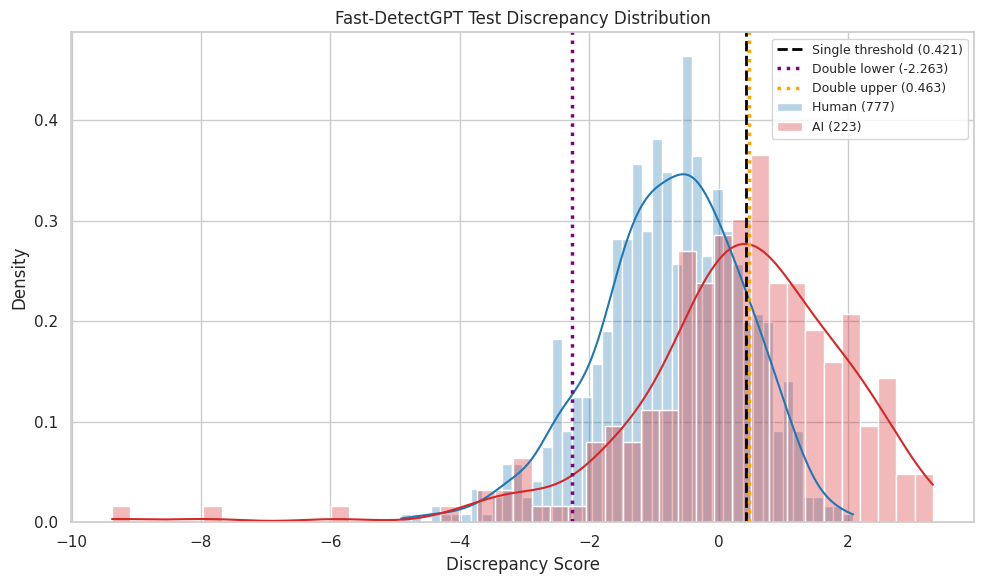

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
label_names = {0: "Human", 1: "AI"}
colors = {0: "#1f77b4", 1: "#d62728"}

plt.figure(figsize=(10, 6))
ax = plt.gca()

for label in [0, 1]:
    subset = test_scores_df[test_scores_df["label"] == label]["discrepancy_score"].dropna()
    sns.histplot(
        subset,
        bins=45,
        stat="density",
        kde=True,
        color=colors[label],
        alpha=0.32,
        label=f"{label_names[label]} ({len(subset)})",
        ax=ax,
    )

ax.axvline(best_single_threshold, color="black", linestyle="--", linewidth=2, label=f"Single threshold ({best_single_threshold:.3f})")
ax.axvline(best_double_lower, color="purple", linestyle=":", linewidth=2.5, label=f"Double lower ({best_double_lower:.3f})")
ax.axvline(best_double_upper, color="orange", linestyle=":", linewidth=2.5, label=f"Double upper ({best_double_upper:.3f})")

ax.set_title("Fast-DetectGPT Test Discrepancy Distribution")
ax.set_xlabel("Discrepancy Score")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
